C:\Users\admin\AppData\Local\Temp\ipykernel_13592\2075172171.py:8: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  temperature_2m = df.pivot("Latitude", "Longitude", "Temperature").values


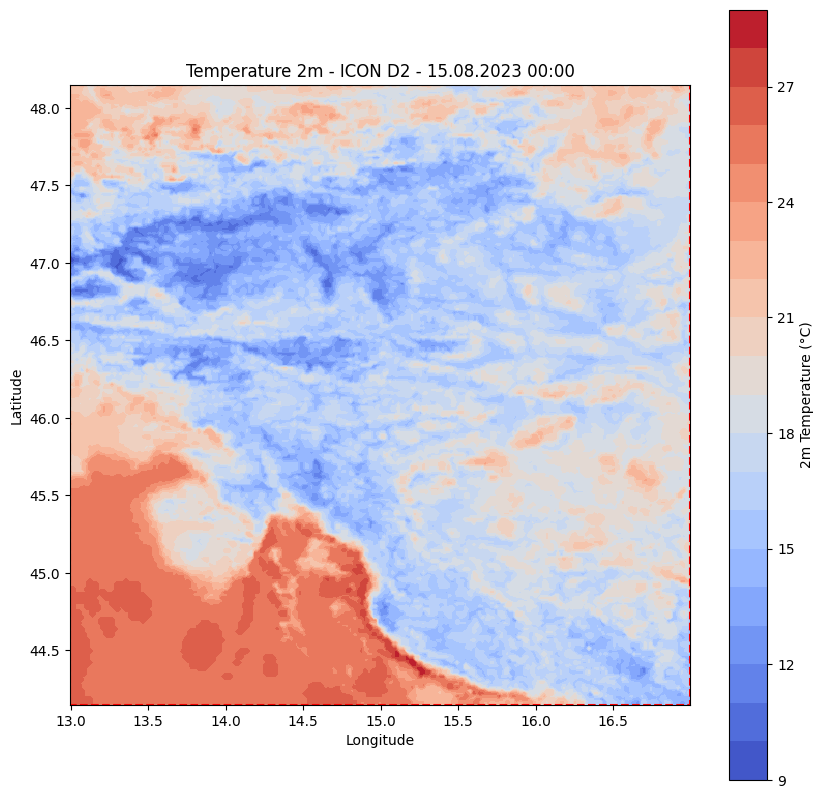

In [34]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon

# Read the temperature data
df = pd.read_csv('../data/test/temperature/temperature_data_2_2_2_2.csv')
temperature_2m = df.pivot("Latitude", "Longitude", "Temperature").values
lat_values = df['Latitude'].unique()
lon_values = df['Longitude'].unique()

# Load the world map with medium resolution
world = gpd.read_file('../data/shapes/shape/ne_10m_admin_0_countries/ne_10m_admin_0_countries.shp')

# Define the neighboring countries
countries = ['Slovenia', 'Austria', 'Italy', 'Hungary', 'Croatia']

# Filter the neighboring countries
region = world[world['NAME'].isin(countries)]

# Create bounding box for the region
latitude_center, longitude_center = 46.1512, 14.9955
lat_min = latitude_center - 2
lat_max = latitude_center + 2
lon_min = longitude_center - 2
lon_max = longitude_center + 2

bbox_polygon = Polygon([(lon_min, lat_min), (lon_min, lat_max), (lon_max, lat_max), (lon_max, lat_min)])

# Plot the bounding areas with detailed geometries
fig, ax = plt.subplots(figsize=(10, 10))
region.plot(ax=ax, color='lightgrey', edgecolor='black')
gpd.GeoSeries(bbox_polygon).boundary.plot(ax=ax, color='red', linestyle='--')

# Plot the 2m temperature within bounding box
plt.contourf(lon_values, lat_values, temperature_2m, 20, cmap='coolwarm', alpha=1.0)
plt.colorbar(label="2m Temperature (°C)")

plt.xlim(lon_min, lon_max)
plt.ylim(lat_min, lat_max)
plt.title("Temperature 2m - ICON D2 - 15.08.2023 00:00")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()
